In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

In [27]:
import sys
import os

sys.path.insert(0, os.path.abspath("../sage")) # go back to root folder to access sage folder
from sage_base import Sage_Explainer

In [28]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

In [37]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [38]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [29]:
target = diabetes.target
model = LinearRegression()
model.fit(df, target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
explainer = Sage_Explainer(model.predict)
explainer.fit(df)

In [31]:
instance = df.iloc[0].to_dict()
sensitivities = explainer.explain(instance)
print("sensitivities from explainer")
for feature, val in sensitivities.items():
    print(f"{feature:8}: {val:>10.4f}")

sensitivities from explainer
age     :   -10.0099
sex     :  -239.8156
bmi     :   519.8459
bp      :   324.3846
s1      :  -792.1756
s2      :   476.7390
s3      :   101.0433
s4      :   177.0632
s5      :   751.2737
s6      :    67.6267


In [32]:
print("actual linear model coefficients")
for feature, coef in zip(df.columns, model.coef_):
    print(f"{feature:8}: {coef:>10.4f}")

actual linear model coefficients
age     :   -10.0099
sex     :  -239.8156
bmi     :   519.8459
bp      :   324.3846
s1      :  -792.1756
s2      :   476.7390
s3      :   101.0433
s4      :   177.0632
s5      :   751.2737
s6      :    67.6267


In [33]:
# sage sensitivity values align with linear model coefficients, showing it found correct slopes

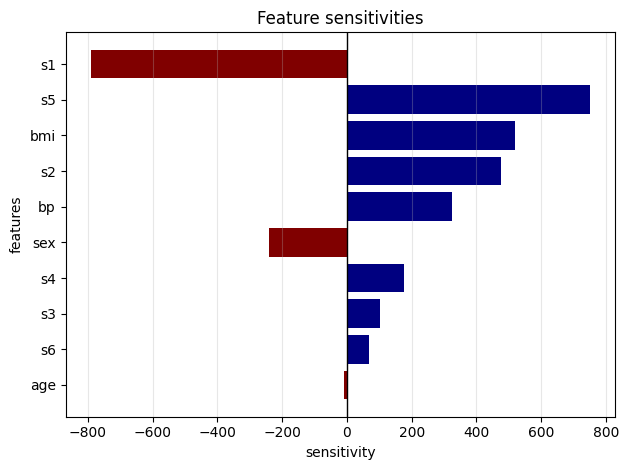

In [34]:
explainer.graph() # wow awesome graph

In [35]:
explainer_rel = Sage_Explainer(model.predict)
explainer_rel.fit(df, relative_sensitivities=True) 
# this time use relative sensitivities on more understandable features

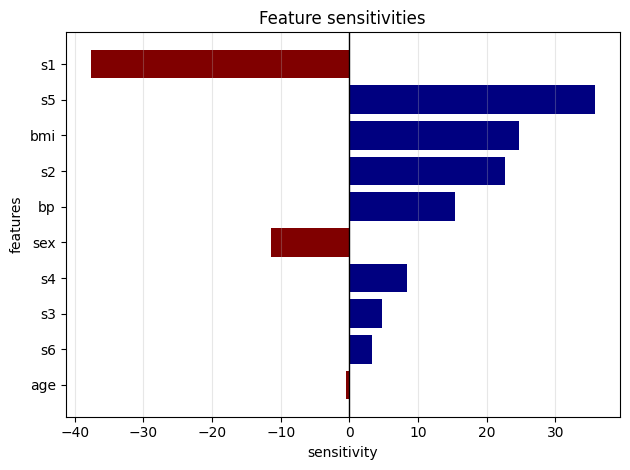

In [ ]:
explainer_rel.graph(df.iloc[0]) 
# these are now compared relative to each other
# basically no difference compared to original (non relative) analysis because features were already normalized (see df.head())